# Preprocessing

## Cleaning

In [ ]:
df = data[["score", "content"]].rename(columns={"score": "Rating", "content": "Review"})
df.head(5)

,Rating,Review
0,5,terbaik
1,5,alhamdulillah puas dgn aplikasi in
2,5,ok
3,5,bagus
4,5,shopee mantap banyak bonusnya


In [ ]:
import re
import string
import nltk

# menghapus simbol
def symbols(text):
    if text is not None and isinstance(text, str):
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        return text
    return text

# menghapus emoji
def emoji(text):
    if text is not None and isinstance(text, str):
        emoji = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               "]+", flags=re.UNICODE)
        return emoji.sub(r'', text)

# remove number and username

def num_use(text):
  if text is not None and isinstance(text, str):
    text = re.sub(r'[0-9]+', '', text) # remove numbers
    text = re.sub(r'[^\w\s]', '', text) # remove username
    return text
  return text

def text_cleaning(text):
  if text is not None and isinstance(text, str):
    text = text.replace('\n',' ')
    text = text.translate(str.maketrans('','',string.punctuation))
    text = text.strip(' ')
    return text

df['cleaning'] = df['Review'].copy()

# Apply Cleaning FUnctions Sequentially
df['cleaning'] = df['cleaning'].apply(lambda x: symbols(x))
df['cleaning'] = df['cleaning'].apply(lambda x: emoji(x))
df['cleaning'] = df['cleaning'].apply(lambda x: num_use(x))
df['cleaning'] = df['cleaning'].apply(lambda x: text_cleaning(x))
df.head(5)

,Rating,Review,cleaning
0,5,terbaik,terbaik
1,5,alhamdulillah puas dgn aplikasi in,alhamdulillah puas dgn aplikasi in
2,5,ok,ok
3,5,bagus,bagus
4,5,shopee mantap banyak bonusnya,shopee mantap banyak bonusnya


# Casefolding

In [ ]:
# mengubah huruf karakter menjadi huruf kecil
def casefoldingtext(text):
  if isinstance(text, str):
    text_lower = text.lower()
    return text_lower
  else:
    return text

df['case folding'] = df['cleaning'].apply(lambda x: casefoldingtext(x))
df.head(5)

,Rating,Review,cleaning,case folding
0,5,terbaik,terbaik,terbaik
1,5,alhamdulillah puas dgn aplikasi in,alhamdulillah puas dgn aplikasi in,alhamdulillah puas dgn aplikasi in
2,5,ok,ok,ok
3,5,bagus,bagus,bagus
4,5,shopee mantap banyak bonusnya,shopee mantap banyak bonusnya,shopee mantap banyak bonusnya


## Normalization

In [ ]:
import pandas as pd

def normalization(text, kamus_tidak_baku):
    if not isinstance(text, str):
        return "", [], [], []

    words = text.split()

    replaced_words = []
    kata_baku = []
    kata_asli = []
    kata_asli_hash = []

    for w in words:
        if w in kamus_tidak_baku:
            baku = kamus_tidak_baku[w]
            if isinstance(baku, str) and baku.isalpha():
                replaced_words.append(baku)
                kata_baku.append(baku)
                kata_asli.append(w)
                kata_asli_hash.append(hash(w))
            else:
                replaced_words.append(w)
        else:
            replaced_words.append(w)

    return " ".join(replaced_words), kata_baku, kata_asli, kata_asli_hash
df.head()

,Rating,Review,cleaning,case folding
0,5,terbaik,terbaik,terbaik
1,5,alhamdulillah puas dgn aplikasi in,alhamdulillah puas dgn aplikasi in,alhamdulillah puas dgn aplikasi in
2,5,ok,ok,ok
3,5,bagus,bagus,bagus
4,5,shopee mantap banyak bonusnya,shopee mantap banyak bonusnya,shopee mantap banyak bonusnya


In [ ]:
import pandas as pd

def normalization(text, kamus_tidak_baku):
    if not isinstance(text, str): # kalau teks bukan string maka tidak memproses dan mengembalikan default kosong
        return "", [], [], []

    words = text.split()

    replaced_words = []
    kata_baku = [] # daftar kata baku yang dipakai untuk mengganti
    kata_asli = [] # daftar kata asli(tidak baku) yang diganti
    kata_asli_hash = [] # daftar dari kata asli yang diganti

    for w in words:
        if w in kamus_tidak_baku:
            baku = kamus_tidak_baku[w]
            if isinstance(baku, str) and baku.isalpha(): # isinya huruf aja
                replaced_words.append(baku)
                kata_baku.append(baku)
                kata_asli.append(w)
                kata_asli_hash.append(hash(w))
            else:
                replaced_words.append(w)
        else:
            replaced_words.append(w)

    return " ".join(replaced_words), kata_baku, kata_asli, kata_asli_hash

In [ ]:
df[['normalization', 'Kata_Baku', 'Kata_Tidak_Baku', 'Kata_Tidak_Baku_Hash']] = df['case folding'].apply(lambda x: pd.Series(normalization(x, kamus_tidak_baku)))
df = pd.DataFrame(df[['Rating','Review','cleaning','case folding','normalization']])
df.head(5)

,Rating,Review,cleaning,case folding,normalization
0,5,terbaik,terbaik,terbaik,terbaik
1,5,alhamdulillah puas dgn aplikasi in,alhamdulillah puas dgn aplikasi in,alhamdulillah puas dgn aplikasi in,alhamdulillah puas dengan aplikasi ini
2,5,ok,ok,ok,ok
3,5,bagus,bagus,bagus,bagus
4,5,shopee mantap banyak bonusnya,shopee mantap banyak bonusnya,shopee mantap banyak bonusnya,shopee mantap banyak bonusnya


## Tokenization

In [ ]:
def tokenize(text):
  kalimat = text.split()
  return kalimat

df['tokenize'] = df['normalization'].apply(lambda x: tokenize(x))
df.head(5)

,Rating,Review,cleaning,case folding,normalization,tokenize
0,5,terbaik,terbaik,terbaik,terbaik,[terbaik]
1,5,alhamdulillah puas dgn aplikasi in,alhamdulillah puas dgn aplikasi in,alhamdulillah puas dgn aplikasi in,alhamdulillah puas dengan aplikasi ini,"[alhamdulillah, puas, dengan, aplikasi, ini]"
2,5,ok,ok,ok,ok,[ok]
3,5,bagus,bagus,bagus,bagus,[bagus]
4,5,shopee mantap banyak bonusnya,shopee mantap banyak bonusnya,shopee mantap banyak bonusnya,shopee mantap banyak bonusnya,"[shopee, mantap, banyak, bonusnya]"


# Stopwords

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
stop_words =stopwords.words('indonesian')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
Stop_id = set(stopwords.words('indonesian'))
Stop_en = set(stopwords.words('english'))
listStopwords = Stop_id.union(Stop_en)

listStopwords.update(['yu','iya','yaa','nya','na','sih','ku',"di",'ya','loh','kah','woi','woii','woy'])

def text_stopwords(text):
    return [x for x in text if x.lower() not in listStopwords]

df['text stopword'] = df['tokenize'].apply(lambda x: text_stopwords(x))
df.head(5)


,Rating,Review,cleaning,case folding,normalization,tokenize,text stopword
0,5,terbaik,terbaik,terbaik,terbaik,[terbaik],[terbaik]
1,5,alhamdulillah puas dgn aplikasi in,alhamdulillah puas dgn aplikasi in,alhamdulillah puas dgn aplikasi in,alhamdulillah puas dengan aplikasi ini,"[alhamdulillah, puas, dengan, aplikasi, ini]","[alhamdulillah, puas, aplikasi]"
2,5,ok,ok,ok,ok,[ok],[ok]
3,5,bagus,bagus,bagus,bagus,[bagus],[bagus]
4,5,shopee mantap banyak bonusnya,shopee mantap banyak bonusnya,shopee mantap banyak bonusnya,shopee mantap banyak bonusnya,"[shopee, mantap, banyak, bonusnya]","[shopee, mantap, bonusnya]"


## Stemming

In [ ]:
!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.7 MB/s eta 0:00:00


In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(text):
  return [stemmer.stem(word) for word in text]

df['stem_text'] = df['text stopword'].apply(lambda x: ' '.join(stem_text(x)))
df.head(5)

,Rating,Review,cleaning,case folding,normalization,tokenize,text stopword,stem_text
0,5,terbaik,terbaik,terbaik,terbaik,[terbaik],[terbaik],baik
1,5,alhamdulillah puas dgn aplikasi in,alhamdulillah puas dgn aplikasi in,alhamdulillah puas dgn aplikasi in,alhamdulillah puas dengan aplikasi ini,"[alhamdulillah, puas, dengan, aplikasi, ini]","[alhamdulillah, puas, aplikasi]",alhamdulillah puas aplikasi
2,5,ok,ok,ok,ok,[ok],[ok],ok
3,5,bagus,bagus,bagus,bagus,[bagus],[bagus],bagus
4,5,shopee mantap banyak bonusnya,shopee mantap banyak bonusnya,shopee mantap banyak bonusnya,shopee mantap banyak bonusnya,"[shopee, mantap, banyak, bonusnya]","[shopee, mantap, bonusnya]",shopee mantap bonus


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15984 entries, 0 to 19999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Rating         15984 non-null  int64 
 1   Review         15984 non-null  object
 2   cleaning       15984 non-null  object
 3   case folding   15984 non-null  object
 4   normalization  15984 non-null  object
 5   tokenize       15984 non-null  object
 6   text stopword  15984 non-null  object
 7   stem_text      15984 non-null  object
dtypes: int64(1), object(7)
memory usage: 1.1+ MB


In [ ]:
df.isna().sum()

,0
Rating,0
Review,0
cleaning,0
case folding,0
normalization,0
tokenize,0
text stopword,0
stem_text,0


# Wordcloud

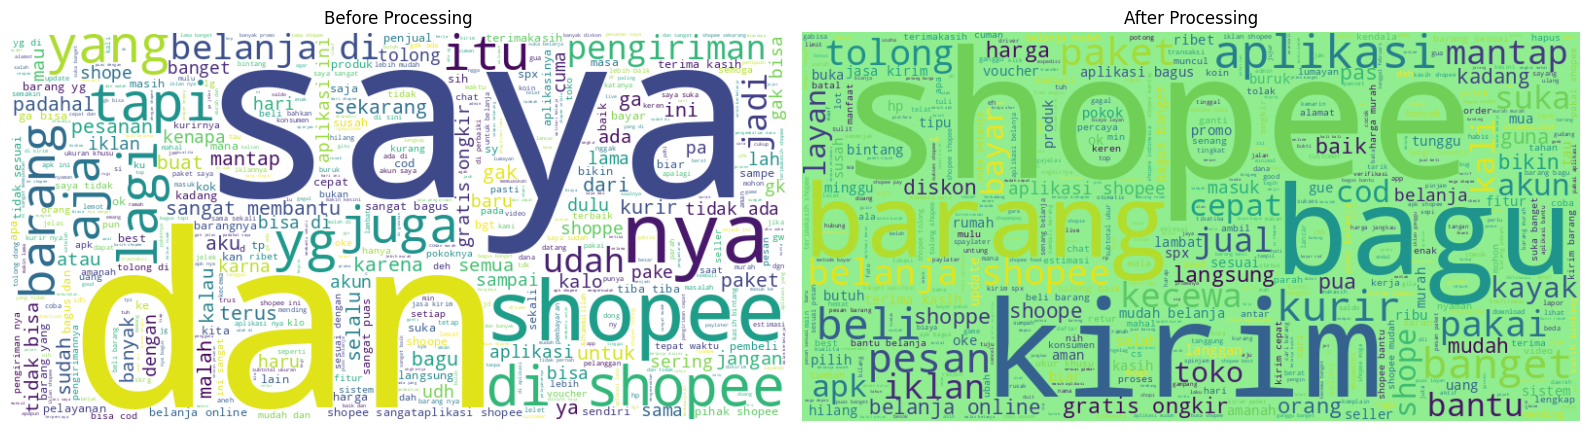

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, ImageColorGenerator


# visualisasi before dan after setelah di processing
txt_before = ' '.join(df['Review'].astype(str).tolist())
txt_after = ' '.join(df['stem_text'].astype(str).tolist())

# workcloud
wordcloud_before = WordCloud(max_words = 500,width=800, height=400, background_color='white').generate(txt_before)
wordcloud_after = WordCloud(max_words = 500,width=800, height=400, background_color='lightgreen').generate(txt_after)

plt.figure(figsize=(16,8))

# before
plt.subplot(1, 2, 1)
plt.title('Before Processing')
plt.imshow(wordcloud_before, interpolation='bilinear')
plt.axis('off')

# after
plt.subplot(1, 2, 2)
plt.title('After Processing')
plt.imshow(wordcloud_after, interpolation='bilinear')
plt.axis('off')


plt.tight_layout()
plt.show()

In [ ]:
file_path = 'Hasil_Preprocessing.csv'
df.to_csv(file_path, index=False, encoding='utf-8')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15984 entries, 0 to 19999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Rating         15984 non-null  int64 
 1   Review         15984 non-null  object
 2   cleaning       15984 non-null  object
 3   case folding   15984 non-null  object
 4   normalization  15984 non-null  object
 5   tokenize       15984 non-null  object
 6   text stopword  15984 non-null  object
 7   stem_text      15984 non-null  object
dtypes: int64(1), object(7)
memory usage: 1.1+ MB
